IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# TD-TME10: Apprentissage non-supervisé (2)

L'objectif de ce TME est d'implémenter l'algorithme des $K$-moyennes.

<font size="+1" color="RED"><b>[Q]</b></font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

21302088 Alexandre PARANT - 21315491 Marc-Antoine XIA

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

Tout en haut de cette page, cliquer sur <tt>tme-10</tt> et rajouter à la suite de <tt>tme-10</tt> les noms des membres du binômes séparés par un tiret.

<font color="RED" size="+1">IMPORTANT: soumission de votre fichier final</font>

**Nom à donner au fichier à poster** : *tme-10-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le notebook tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Echancier pour la soumission de votre compte-rendu:**
- le compte-rendu d'une séance doit être remis obligatoirement <font color="RED">avant la séance suivante</font>.

**Le compte-rendu est soumis sur la page Moodle.**
Pour un binôme, le compte-rendu ne doit être rendu qu'une seule fois sur un des deux comptes du binömes (et pas en soumettant sur chacun des comptes). Les 2 noms doivent être bien indiqués dans le notebook.

## Préparation

In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# - - - - - - - - - - - - - - - - - -
# Information sur l'environnent utilisé ici:
print("Version python et des librairies:")
print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

# --------------------------------
# Nouveau : pour les dendrogrammes (si besoin) :
import scipy
print("\tscipy: ",scipy.__version__)
# --------------------------------


/tmp/ipykernel_326469/3615517645.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Version python et des librairies:
	Python  3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]
	pandas:  2.2.0
	numpy:  1.24.2
	matplotlib:  3.6.3
	scipy:  1.10.1


### Mise à jour de votre librairie `IADS` 

Si vous ne l'avez pas encore fait une fois séance précédente terminée, pensez à copier toutes vos fonctions du TME précédent (classification ascendante hiérarchique) dans le fichier `Clustering.py` de votre librairie.

Une fois ce TME terminé, les fonctions et classes écrites devront être ajoutées dans le fichier `Clustering.py` de votre répertoire `iads`.

In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering   <-------------- ***** NOUVEAU ******
from iads import Clustering as clust


### Chargement du fichier "base_2D.csv"

Pour tester les fonctions, on utilise un dataset jouet: charger le fichier `base_2D.csv` et le normaliser (voir TME 9).

Il y a 14 exemples dans la base normalisée.


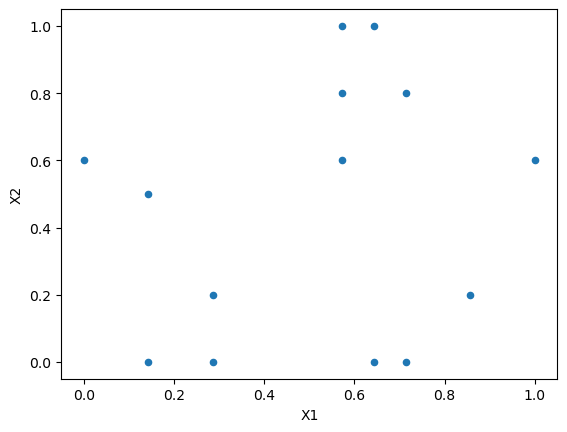

In [5]:
######## A COMPLETER
data_2D_norm = clust.normalisation(pd.read_csv("data/base-2D.csv"))
X1_values = data_2D_norm["X1"]
X2_values = data_2D_norm["X2"]

data_2D_norm.plot.scatter("X1", "X2")

print("Il y a", len(data_2D_norm), "exemples dans la base normalisée.")


## Apprentissage non supervisé : l'algorithme des $K$-moyennes

### Implémentation des fonctions

On définit la classe `KMoyennes` qui fournira les fonctions implémentant l'algorithme des $K$-moyennes.

La classe est donnée sous forme incomplète ci-dessous : pour la compléter, suivre l'ordre des questions posées dans le reste de ce notebook, elles permettent de remplir au fur et à mesure les définitions des fonctions de cette classe.


In [156]:
class KMoyennes():
    """ Classe implémentant l'algorithme des K-moyennes
    """
    def __init__(self, K, distance=clust.DistanceEuclidienne() ):
        """ Argument:
                - K (int) : nombre de clusters voulus
                - distance (Distance): mesure de distance entre 2 exemples
                  par défaut: distance euclidienne
        """
        if K<1:
            raise TypeError("KMoyennes: K doit être strictement plus grand que 0 !")
        self.__K = K 
        self.__distance = distance

    def get_K(self):
        """ Accesseur de la variable __K
        """
        return self.__K

    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet
        """
        return f"KMoyennes (K={self.__K}, {self.__distance})"
 
    def inertie_cluster(self,Ens):
        """ Arguments :
                - Ens: array qui représente un cluster
            Hypothèse: len(Ens)> >= 2
            L'inertie est la somme (au carré) des distances des points au centroide.
        """
        data = np.array(Ens)
        centroide = np.mean(data, axis=0)
        return np.sum(self.__distance.calcule(centroide, data)**2)
    
    def init(self,Ens):
        """ Argument :
                - Ens: Array contenant n exemples
        """
        ind = np.arange(0, len(Ens), 1)
        np.random.shuffle(ind)
        return np.array(Ens)[ind[:self.__K]]


    def plus_proche(self,exemple,Centres):
        """ Arguments :
                - exemple : Array contenant un exemple
                - Centres : Array contenant les K centres
        """

        # print("centres: ", Centres)
        # print("ex: ", exemple)
        return np.argsort(self.__distance.calcule(np.array(exemple), np.array(Centres)))[0]


    def affecte_cluster(self,Base,Centres):
        """ Arguments :
                - Base: Array contenant la base d'apprentissage
                - Centres : Array contenant des centroides
        """
        d = dict()
        for i in range(0,len(Base)):
            c = self.plus_proche(Base.iloc[i],Centres)
            if c not in d:
                d[c] = list()
            d[c].append(i)
        return d
        
                       
    def centroides(self,Base,U):
        """ Arguments :
                - Base : Array contenant la base d'apprentissage
                - U : Dictionnaire d'affectation
        """ 

        # print(U)
        res = []
        for cleCluster in U:
            data = np.array(Base)[U[cleCluster]]
            centroide = np.mean(data, axis=0)
            res.append(centroide)
            
        return res

    def inertie_globale(self,Base, U):
        """ Arguments :
                - Base : Array pour la base d'apprentissage
                - U : Dictionnaire d'affectation
        """      
        sumInertie = 0
        for cleCluster in U:
            data = np.array(Base)[U[cleCluster]]
            sumInertie += self.inertie_cluster(data)
        return sumInertie
            

    def train(self,Base, epsilon, iter_max, verbose=False):
        """ Arguments :
                - Base : Array pour la base d'apprentissage
                - epsilon : réel >0
                - iter_max : entier >1
                - verbose: pour afficher des messages de débuggage si besoin
        """        
        centres = self.init(Base)
        lastInertieGlobal = None
        for i in range(iter_max):
            U = self.affecte_cluster(Base, centres)
            centres = self.centroides(Base, U)
            newInertieGlobal = self.inertie_globale(Base, U)
            if lastInertieGlobal != None:
                diff = abs(lastInertieGlobal - newInertieGlobal)
                if verbose:
                    print(f"iteration n°{i} : Inertie = {newInertieGlobal} Difference =  {diff}")
                if diff < epsilon:
                    break
            lastInertieGlobal = newInertieGlobal
        return np.array(centres), self.affecte_cluster(Base, centres)

<font size="+1" color="RED"><b>[Q]</b></font> Définir le constructeur de cette classe : pour initialiser une instance, on donne la valeur de $K$ choisie, ainsi qu'une mesure de distance (*cf* la classe `Distance` du TME 8). Par défaut, on choisit la distance euclidienne.



In [157]:
#  Exemple :

kmeans1= KMoyennes(K=3)

print("Instance de KMoyennes :", kmeans1)

Instance de KMoyennes : KMoyennes (K=3, Distance euclidienne)


Pour toutes les questions qui suivent, les fonctions sont à définir dans la classe `KMoyennes`. 


### Inertie d'un cluster
<font size="+1" color="RED"><b>[Q]</b></font>Compléter la fonction <code>inertie_cluster</code> qui, étant donné un  ensemble d'exemples (sous la forme d'un dataframe ou d'un np.array) contenant au moins 2 exemples, rend la valeur de l'inertie de cet ensemble telle qu'elle a été définie dans le cours.

In [158]:
print(f"inertie de l'ensemble : {kmeans1.inertie_cluster(data_2D_norm):1.4f}")


inertie de l'ensemble : 2.9760


<font size="+1" color="RED"><b>[Q]</b></font>  Compléter la fonction <code>init()</code> qui étant donné une base d'apprentissage de $n$ exemples rend un `np.array` composé de $K$ exemples tirés aléatoirement dans la base. On fait l'hypothèse que $n\geq K$.


In [159]:
np.random.seed(42)   # supprimer cette ligne une fois la mise au point terminée

# Par exemple (mais vous ne devriez pas pouvoir retrouver exactement les mêmes !)
Centroides_test = kmeans1.init(data_2D_norm)
Centroides_test

array([[0.64285714, 1.        ],
       [0.71428571, 0.8       ],
       [0.        , 0.6       ]])

Affichage des centres de clusters choisis.

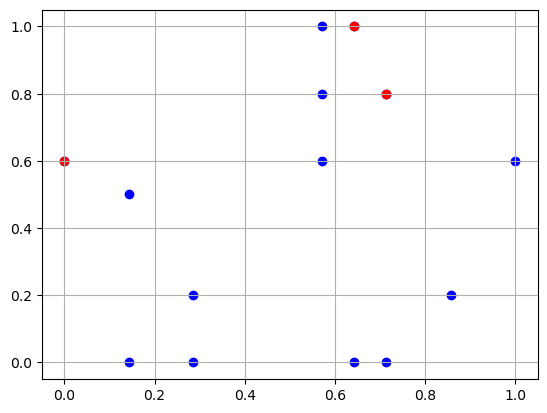

In [160]:
plt.scatter(data_2D_norm['X1'],data_2D_norm['X2'],color='blue')
plt.scatter(Centroides_test[:,0],Centroides_test[:,1],color='red')
plt.grid() 

<font size="+1" color="RED"><b>[Q]</b></font>  Ecrire la fonction <code>plus_proche()</code> qui, étant donné un exemple et un array contenant un ensemble de centroides, rend l'indice du centroide dont l'exemple est le plus proche.
En cas d'égalité de distance, le centroide de plus petit indice est choisi.

In [161]:
# Exemple (vérifier le résultat avec l'affichage graphique réalisé précédemment):
for i in range(0,len(data_2D_norm)):
    pproche = kmeans1.plus_proche(data_2D_norm.iloc[i],Centroides_test)
    print("L'exemple ",i," est le plus proche du centroide ",pproche)

L'exemple  0  est le plus proche du centroide  2
L'exemple  1  est le plus proche du centroide  2
L'exemple  2  est le plus proche du centroide  2
L'exemple  3  est le plus proche du centroide  2
L'exemple  4  est le plus proche du centroide  2
L'exemple  5  est le plus proche du centroide  1
L'exemple  6  est le plus proche du centroide  1
L'exemple  7  est le plus proche du centroide  0
L'exemple  8  est le plus proche du centroide  1
L'exemple  9  est le plus proche du centroide  0
L'exemple  10  est le plus proche du centroide  1
L'exemple  11  est le plus proche du centroide  1
L'exemple  12  est le plus proche du centroide  1
L'exemple  13  est le plus proche du centroide  1


#### Matrice d'affectation

Etant donné une base d'apprentissage, on représente une partition de cette base en K clusters à l'aide d'une matrice U contenant n lignes (une par exemple) et K colonnes (une par cluster) et telle que les contraintes suivantes sont vérifiées: 
- U[i,j] = 1 si l'exemple i appartient au cluster j
- U[i,j] = 0 si l'exemple i n'appartient pas au cluster j
- un exemple appartient à un et un seul cluster
- un cluster contient au moins un exemple

On appelle **matrice d'affectation** une telle matrice U.


<font size="+1" color="RED"><b>[Q]</b></font>  Donner une expression mathématique (pas du Python) des 2 dernières contraintes que vérifie une matrice d'affectation.

pour tous points appartenent au data, il existe un cluster tq le points lui appartient mais pour tous les cluster différents, il ne leur appartient pas

Pour tous cluster Ck appartenent à notre ensemble de donnée
, il existe un points de data tq appartient à Ck

#### Implémentation en Python
Nous utilisons un dictionnaire pour représenter d'une matrice d'affectation: 
- les clés de ce dictionnaire correspondent aux $K$ indices des clusters
- les valeurs correspondent à des listes d'indices d'exemples (leur indice dans la base d'apprentissage)

Dans tout ce qui suit, une "matrice d'affectation" sera un tel dictionnaire.


<font size="+1" color="RED"><b>[Q]</b></font>  Ecrire la fonction <code>affecte_cluster()</code> qui, étant donné une base d'apprentissage et un ensemble de $K$ centroïdes, rend la matrice d'affectation des exemples de la base aux clusters représentés par chaque centroïde.

In [162]:
DictAffect = kmeans1.affecte_cluster(data_2D_norm, Centroides_test)
DictAffect

{2: [0, 1, 2, 3, 4], 1: [5, 6, 8, 10, 11, 12, 13], 0: [7, 9]}

#### Ensemble des centroides
A partir de la matrice d'affectation, on peut déterminer les centroides de chaque cluster. 

<font size="+1" color="RED"><b>[Q]</b></font>  Ecrire la fonction <code>centroides()</code> qui, étant donné une base d'apprentissage et une matrice d'affectation, rend l'ensemble des centroides correspondants aux clusters définis dans la matrice d'affectation.

In [163]:
kmeans1.centroides(data_2D_norm, DictAffect)

[array([0.17142857, 0.26      ]),
 array([0.7244898 , 0.42857143]),
 array([0.60714286, 1.        ])]

### Inertie globale d'une partition

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction `inertie_globale()` qui, étant donné une base d'apprentissage et une matrice d'affectation, rend la valeur de l'inertie globale du partitionnement correspondant.


In [164]:
print(f'Inertie globale: {kmeans1.inertie_globale(data_2D_norm,DictAffect):1.4f}')

Inertie globale: 1.2732


### Algorithme des K-moyennes

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire une fonction <code>train()</code> qui implémente l'algorithme des $K$ moyennes pour retourner un ensemble de centroides et une matrice d'affectation. Cette fonction prend en argument une base d'apprentissage, un réel *epsilon*$>0$ et un entier *iter_max*$>1$. Le réel *epsilon* sert de critère de convergence, et l'entier *iter_max* est utilisé pour fixer un nombre d'itérations maximal servant à arrêter le calcul. 
L'option `verbose` (par défaut à `False`) permet d'afficher un message de la forme:

        iteration n°2 : Inertie = 1.5128	Difference = 0.7354

où à chaque itération, on affiche la valeur de l'inertie globale, et la différence d'inertie.


In [165]:
np.random.seed(42)   # supprimer cette ligne une fois la mise au point terminée

kmeans2 = KMoyennes(K=2)
print("Instance de KMoyennes :", kmeans2)

les_centres, l_affectation = kmeans2.train(data_2D_norm, 0.05, 100,verbose=True)

print("\nAffichage des centres:\n",les_centres)
print("Affichage des affectations:\n",l_affectation)

Instance de KMoyennes : KMoyennes (K=2, Distance euclidienne)
iteration n°1 : Inertie = 1.5128163265306123 Difference =  0.7354149659863944
iteration n°2 : Inertie = 1.392091836734694 Difference =  0.12072448979591832
iteration n°3 : Inertie = 1.392091836734694 Difference =  0.0

Affichage des centres:
 [[0.38392857 0.1875    ]
 [0.67857143 0.8       ]]
Affichage des affectations:
 {0: [0, 1, 2, 3, 4, 8, 10, 12], 1: [5, 6, 7, 9, 11, 13]}


On peut réaliser un affichage couleur des centroïdes trouvés:

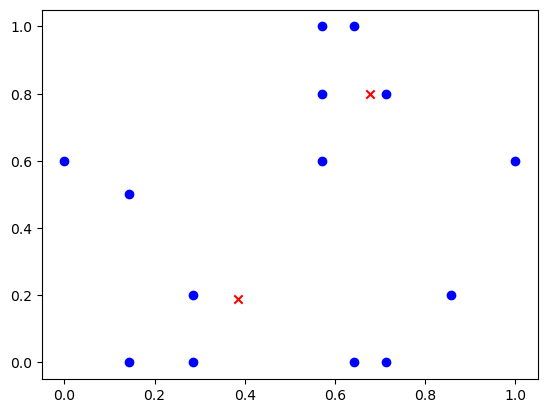

In [166]:
plt.scatter(data_2D_norm['X1'],data_2D_norm['X2'],color='b')
plt.scatter(les_centres[:,0],les_centres[:,1],color='r',marker='x')

<font size="+1" color="RED"><b>[Q]</b></font> A partir de cette question, les fonctions ne sont plus ajoutées dans la classe `KMoyennes`. Ecrire la fonction <code>affiche_resultat()</code> qui permet d'afficher le résultat de l'algorithme en utilisant des couleurs différentes pour les clusters trouvés (pour faire simple, on peut ne considèrer que le cas où K est inférieur à 20).

*Remarque*: La librairie matplotlib permet de manipuler aisément des couleurs:
http://matplotlib.org/api/cm_api.html

Par exemple, on peut utiliser la table des couleurs (colormap) de nom `tab20` qui contient 20 couleurs différentes.

nombre de couleurs différentes 20


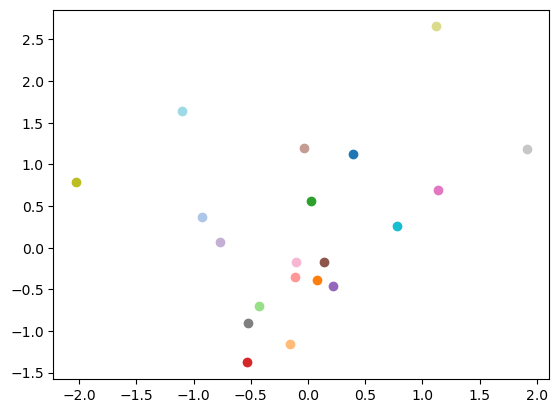

In [167]:
# Librairie pour manipuler les colormaps:
import matplotlib.cm as cm

# on transforme le colormap en couleurs utilisable par plt.scatter:
couleurs = cm.tab20(np.linspace(0, 1, 20))

print("nombre de couleurs différentes",len(couleurs))

# Pour voir ces couleurs, on va afficher 20 points aléatoirement définis:
x = np.random.randn(len(couleurs))
y = np.random.randn(len(couleurs))       

for (x,y,c) in zip(x,y,couleurs):
    plt.scatter(x, y, color=c)
    

In [186]:
import matplotlib.cm as cm

def affiche_resultat(Base,Centres,Affect):
    """ Arguments :
            - ensemble d'exemples
            - ensemble de centroides
            - matrice d'affectation                
    """
    
    # on transforme le colormap en couleurs utilisable par plt.scatter:
    couleurs = cm.tab20(np.linspace(0, 1, 20))
    
    print("nombre de couleurs différentes",len(couleurs))   

    i = 0
    for cle in Affect:
        data = np.array(Base)[Affect[cle]]
        plt.scatter(data[:,0],data[:,1],color=couleurs[i])
        i += 1

    ## Centres
    plt.scatter(les_centres[:,0],les_centres[:,1],color='r',marker='x')
    
        

nombre de couleurs différentes 20


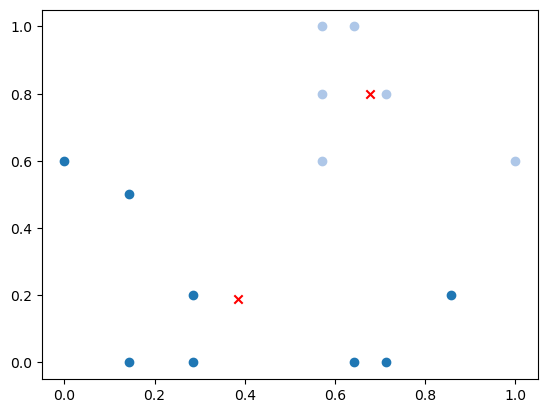

In [187]:
affiche_resultat(data_2D_norm,les_centres,l_affectation)

# Remarque:
#  - les centres sont représentés par des croix rouges

### Un autre dataset pour tester

On étudie les différences de résultats obtenus avec différentes valeurs de $K$ sur la base suivante.

Il y a 23 exemples dans la base.


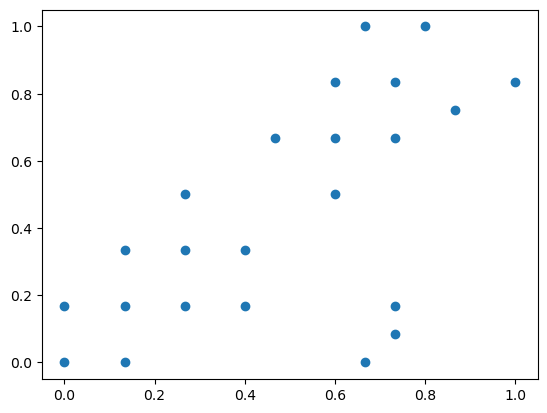

In [189]:
data_2D_diff = clust.normalisation(pd.read_csv("data/base-2D-diff.csv"))

X1_values = data_2D_diff["X1"]
X2_values = data_2D_diff["X2"]

plt.scatter(X1_values, X2_values)

print("Il y a", len(data_2D_diff), "exemples dans la base.")


#### Applications des $K$-moyennes

Instance de KMoyennes : KMoyennes (K=2, Distance euclidienne)
iteration n°1 : Inertie = 1.5104209401709403 Difference =  0.1872480413105413
iteration n°2 : Inertie = 1.5104209401709403 Difference =  0.0

Affichage des centres:
 [[0.31794872 0.18589744]
 [0.70666667 0.775     ]]
Affichage des affectations:
 {0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 14, 16, 17], 1: [10, 11, 12, 13, 15, 18, 19, 20, 21, 22]}
nombre de couleurs différentes 20


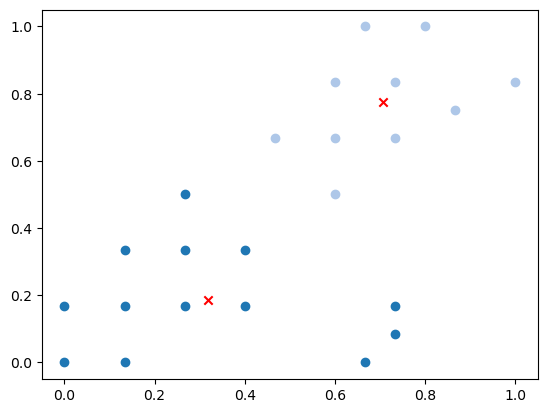

In [190]:
np.random.seed(42)   # supprimer cette ligne une fois la mise au point terminée


# Recherche de 2 clusters dans les données :
# Utiliser les mêmes valeurs pour epsilon et iter_max qu'à l'exécution précédente
kmeans2 = KMoyennes(K=2)
print("Instance de KMoyennes :", kmeans2)

################################### A COMPLETER 
les_centres, l_affectation = kmeans2.train(data_2D_diff, 0.05, 100,verbose=True)
########################################################


print("\nAffichage des centres:\n",les_centres)
print("Affichage des affectations:\n",l_affectation)

affiche_resultat(data_2D_diff,les_centres,l_affectation)


Instance de KMoyennes : KMoyennes (K=3, Distance euclidienne)
iteration n°1 : Inertie = 0.9093441358024692 Difference =  0.0

Affichage des centres:
 [[0.2        0.21666667]
 [0.71851852 0.80555556]
 [0.68333333 0.1875    ]]
Affichage des affectations:
 {0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 1: [10, 12, 13, 15, 18, 19, 20, 21, 22], 2: [11, 14, 16, 17]}
nombre de couleurs différentes 20


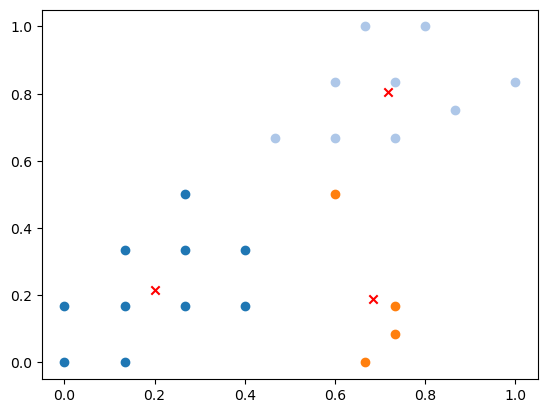

In [191]:
np.random.seed(1)   # supprimer cette ligne une fois la mise au point terminée

# Recherche de 3 clusters dans les données :
# Utiliser les mêmes valeurs pour epsilon et iter_max qu'à l'exécution précédente
kmeans2 = KMoyennes(K=3)
print("Instance de KMoyennes :", kmeans2)

################################### A COMPLETER 
les_centres, l_affectation = kmeans2.train(data_2D_diff, 0.05, 100,verbose=True)
########################################################


print("\nAffichage des centres:\n",les_centres)
print("Affichage des affectations:\n",l_affectation)

affiche_resultat(data_2D_diff,les_centres,l_affectation)


## Beaucoup de points...

On essaye en générant aléatoire 1000 points en 2 dimensions en utilisant la fonction `np.random.multivariate_normal` que l'on a déjà utilisé précédemment. On génère la moitié des points selon une gaussienne centrée sur $(2,1)$ et l'autre moitié des points selon une gaussienne centrée sur $(-2-2)$. 

Taille du dataset généré : 1000 exemples


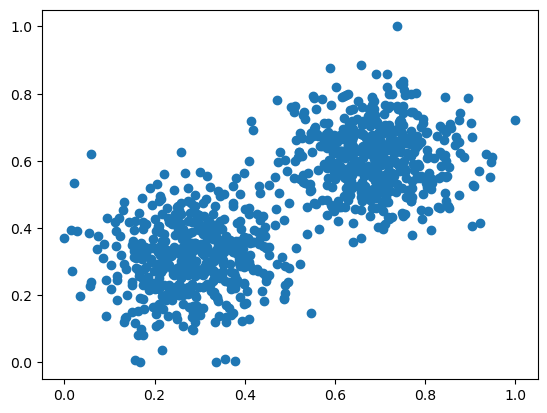

In [216]:
np.random.seed(42)   # on prend 42 comme graine


nb_points = 500 
cov = [[1, 0], [0, 1]]

################################### A COMPLETER 

data_rand1 = np.random.multivariate_normal([2, 1], cov, nb_points)
data_rand2 = np.random.multivariate_normal([-2, -2], cov, nb_points)

data_rand = np.concatenate((data_rand1, data_rand2))

df = pd.DataFrame()
df["X1"] = data_rand[:,0]
df["X2"] = data_rand[:,1]

df = clust.normalisation(df)
data_rand = np.array(df)
########################################################

print("Taille du dataset généré :", data_rand.shape[0], "exemples")
# Affichage des points obtenus:
plt.scatter(data_rand[:,0], data_rand[:,1])



Instance de KMoyennes : KMoyennes (K=2, Distance euclidienne)
iteration n°1 : Inertie = 22.61670614991644 Difference =  30.37028451171527
iteration n°2 : Inertie = 20.303490071441107 Difference =  2.3132160784753317
iteration n°3 : Inertie = 20.267380504743066 Difference =  0.03610956669804111
nombre de couleurs différentes 20


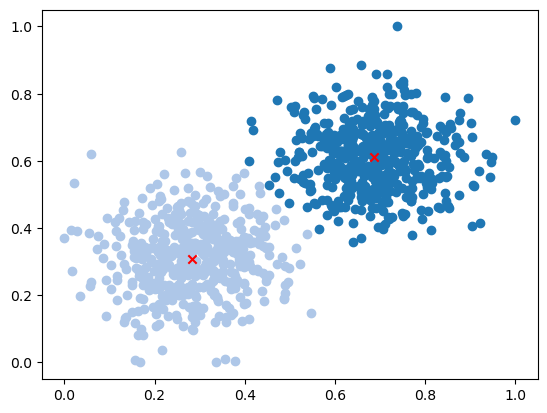

In [219]:
np.random.seed(42)   # supprimer cette ligne une fois la mise au point terminée

# Recherche de 2 clusters dans les données :

kmeans2 = KMoyennes(K=2)
print("Instance de KMoyennes :", kmeans2)

les_centres, l_affectation = kmeans2.train(df, 0.05, 100,verbose=True)

affiche_resultat(df,les_centres,l_affectation)


Instance de KMoyennes : KMoyennes (K=4, Distance euclidienne)
iteration n°1 : Inertie = 14.710049106977433 Difference =  12.451889291462276
iteration n°2 : Inertie = 14.58336289994761 Difference =  0.12668620702982203
iteration n°3 : Inertie = 14.56659262531871 Difference =  0.01677027462890024
nombre de couleurs différentes 20


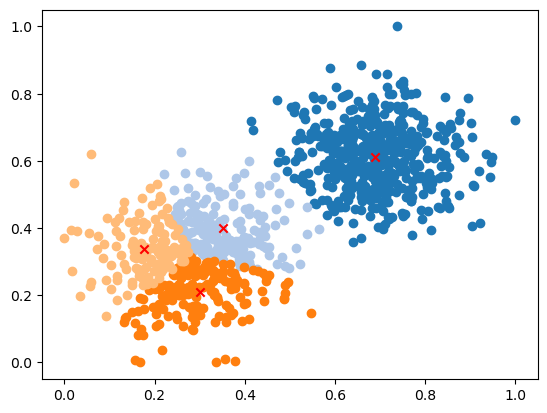

In [220]:
np.random.seed(42)   

# On peut essayer avec plus de clusters que prévu :

kmeans2 = KMoyennes(K=4)
print("Instance de KMoyennes :", kmeans2)

les_centres, l_affectation = kmeans2.train(df, 0.05, 100,verbose=True)

affiche_resultat(data_rand,les_centres,l_affectation)


Instance de KMoyennes : KMoyennes (K=4, Distance euclidienne)
iteration n°1 : Inertie = 14.636389725283156 Difference =  1.0236712497487694
iteration n°2 : Inertie = 14.383052190913167 Difference =  0.2533375343699884
iteration n°3 : Inertie = 14.205347667028423 Difference =  0.1777045238847439
iteration n°4 : Inertie = 14.014635789384045 Difference =  0.1907118776443788
iteration n°5 : Inertie = 13.81845790713106 Difference =  0.19617788225298405
iteration n°6 : Inertie = 13.62432673188669 Difference =  0.19413117524437062
iteration n°7 : Inertie = 13.477811748048143 Difference =  0.14651498383854644
iteration n°8 : Inertie = 13.349454511780362 Difference =  0.12835723626778162
iteration n°9 : Inertie = 13.320025596910549 Difference =  0.029428914869813028
nombre de couleurs différentes 20


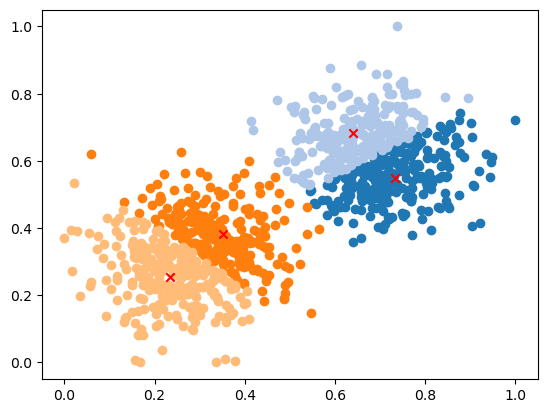

In [221]:
np.random.seed(2026)     # <------------ On change la séquence aléatoire

kmeans2 = KMoyennes(K=4)
print("Instance de KMoyennes :", kmeans2)

les_centres, l_affectation = kmeans2.train(df, 0.05, 100,verbose=True)

affiche_resultat(data_rand,les_centres,l_affectation)


### Evaluation des partitions obtenues

<font size="+1" color="RED"><b>[Q]</b></font>  Ecrire les fonctions `index_Dunn` et `index_XieBeni` qui, étant donné un ensemble d'exemples, un ensemble de centroïdes et une matrice d'affectation, retourne respectivement la valeur de l'index de Dunn et la valeur de l'index de Xie-Beni présentés en cours.

Utiliser ces fonctions pour évaluer les partitions des clusterings précédents avec ces index.

In [288]:
def calculeSepMin(G1,distance=clust.DistanceEuclidienne(), verbose=False):

        if len(G1.shape) == 1:
            return 1
            
        res = 2**64-1
        for i in range(len(G1)):
            dist = np.min(distance.calcule(G1.iloc[i], G1.iloc[:i]))
            dist = min(dist, np.min(distance.calcule(G1.iloc[i], G1.iloc[i+1:])))
            res = min(res, float(dist))
        return res


def index_Dunn(Base, Centres, Affect):
    lkcomp = clust.LinkageComplete()
    codist = 0
    for cle in Affect:
        data = Base.iloc[Affect[cle]]
        codist += lkcomp.calcule(data, data)

    sepmin = calculeSepMin(pd.DataFrame(Centres))
    return codist/sepmin

def index_XieBeni(Base, Centres, Affect):
    distance = clust.DistanceEuclidienne()
    sepmin = calculeSepMin(pd.DataFrame(Centres))

    sumInertie = 0
    for cleCluster in Affect:
        data = Base.iloc[Affect[cleCluster]]
        centroide = np.mean(data, axis=0) 
        sumInertie += np.sum(distance.calcule(centroide, data)**2)

    return sumInertie/sepmin

## Expérimentations

<font size="+1" color="RED"><b>[Q]</b></font>  Expérimenter l'algorithme des k-moyennes sur les données. Etudier l'impact du choix de $K$ sur l'inertie globale finale en traçant la courbe donnant la valeur de l'inertie obtenue pour différentes valeurs de $K$.


<font size="+1" color="RED"><b>[Q]</b></font>  Expérimenter l'algorithme des k-moyennes en modifiant la valeur de epsilon ou de max_iter.


<font size="+1" color="RED"><b>[Q]</b></font>  Expérimenter l'algorithmesur les données de la base `base_Paris` vue dans le TME précédent.

Utiliser votre algorithme de classification ascendante hiérarchique afin de trouver une bonne valeur pour $K$.


In [289]:
data_Paris_norm = clust.normalisation(pd.read_csv("data/base-Paris.csv"))
data_Paris_norm = data_Paris_norm.drop(['Granularité'], axis=1)

kmeans2 = KMoyennes(K=3)
print("Instance de KMoyennes :", kmeans2)

les_centres, l_affectation = kmeans2.train(data_Paris_norm, 0.05, 100,verbose=True)

print("Dunn: ", index_Dunn(data_Paris_norm, les_centres, l_affectation))
print("XieBeni: ", index_XieBeni(data_Paris_norm, les_centres, l_affectation))

Instance de KMoyennes : KMoyennes (K=3, Distance euclidienne)
iteration n°1 : Inertie = 5.177860087397469 Difference =  5.426242752564309
iteration n°2 : Inertie = 0.08891309439233971 Difference =  5.088946993005129
iteration n°3 : Inertie = 0.06926859160672913 Difference =  0.019644502785610585
Dunn:  2.4192935242065485
XieBeni:  0.4024935942987656
